Imports

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [11]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\Expression_Genes_DESeq_Temporal_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\Aldinger2020_Temporal_cortex\\DEA_Genes_DESeq_Temporal_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Aldinger2020\\SraRunTable_Aldinger20.csv"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [12]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
expression_df.head()

,Gene,1038_CTL_TCTX,1614_CTL_TCTX,4724_CTL_TCTX,4725_CTL_TCTX,6355_RTT_TCTX,7773_RTT_TCTX,7783_RTT_TCTX,B7992_RTT_TCTX
0,DDX11L2,15,5,0,4,2,6,3,1
1,WASH7P,35,15,26,37,27,28,14,40
2,ENSG00000238009,0,0,0,2,2,4,2,1
3,WASH9P,11,6,2,10,6,12,4,4
4,ENSG00000228463,21,7,10,23,3,9,6,9


DEA - Import

In [13]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'Gene'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,Gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,INF2,1049.441723,-1.760932,0.205944,-8.550552,1.225008e-17,1.946783e-13
1,PDE1C,571.307430,-1.472649,0.208289,-7.070229,1.546779e-12,1.229071e-08
2,LINC00343,39.805153,-3.128923,0.494815,-6.323426,2.558275e-10,1.355203e-06
3,CP,38.279965,2.528893,0.427671,5.913173,3.355789e-09,1.333255e-05
4,TMPRSS3,82.479030,3.179357,0.550638,5.773948,7.743541e-09,2.461207e-05


Volcano plot

Classification
Non-significant    15515
Up-regulated         215
Down-regulated       162
Name: count, dtype: int64
377
Total tes:
20321


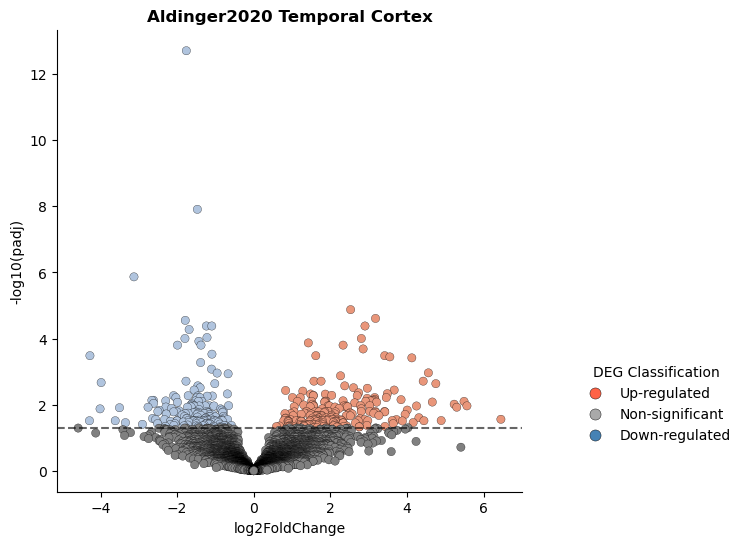

In [25]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Aldinger2020 Temporal Cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['Gene'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['Gene'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['Gene'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['Gene'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['Gene'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DEG Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False)
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [26]:
# Variables
genes = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)

# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Run']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

pca_df




   1038_CTL_TCTX  1614_CTL_TCTX  4724_CTL_TCTX  4725_CTL_TCTX  6355_RTT_TCTX  \
0       0.912909       0.485644       0.000000       0.307527       0.168889   
1       1.613511       1.137917       1.393009       1.677014       1.420399   
2       0.000000       0.000000       0.000000       0.161942       0.168889   
3       0.720204       0.565843       0.170049       0.672616       0.456887   
4       1.160903       0.641818       0.700869       1.242517       0.246455   

   7773_RTT_TCTX  7783_RTT_TCTX  B7992_RTT_TCTX  
0       0.463937       0.315225        0.082018  
1       1.469922       1.097360        1.739812  
2       0.325233       0.217608        0.082018  
3       0.814428       0.406654        0.303333  
4       0.649800       0.573774        0.610210  


,Sample_Name,PC1,PC2,Condition,Run
0,1038_CTL_TCTX,103.458616,-25.195645,Ctrl,SRR8734764
1,1614_CTL_TCTX,-113.983919,-30.478537,Ctrl,SRR8734765
2,4724_CTL_TCTX,70.463964,-28.861178,Ctrl,SRR8734766
3,4725_CTL_TCTX,98.587900,-66.120717,Ctrl,SRR8734767
4,6355_RTT_TCTX,-146.634005,-43.504996,RTT,SRR8734768
5,7773_RTT_TCTX,1.777120,110.609478,RTT,SRR8734769
6,7783_RTT_TCTX,-43.052832,18.580109,RTT,SRR8734770
7,B7992_RTT_TCTX,29.383156,64.971486,RTT,SRR8734771


PCA - Graph

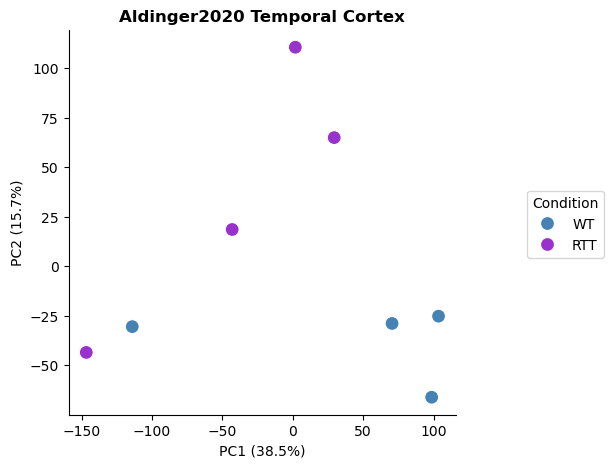

In [27]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : 'WT'})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Aldinger2020 Temporal Cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

     Sample_Name Condition         Run
0  1038_CTL_CCTX      Ctrl  SRR8734756
1  1614_CTL_CCTX      Ctrl  SRR8734757
2  4724_CTL_CCTX      Ctrl  SRR8734758
3  4725_CTL_CCTX      Ctrl  SRR8734759
4  6355_RTT_CCTX       RTT  SRR8734760


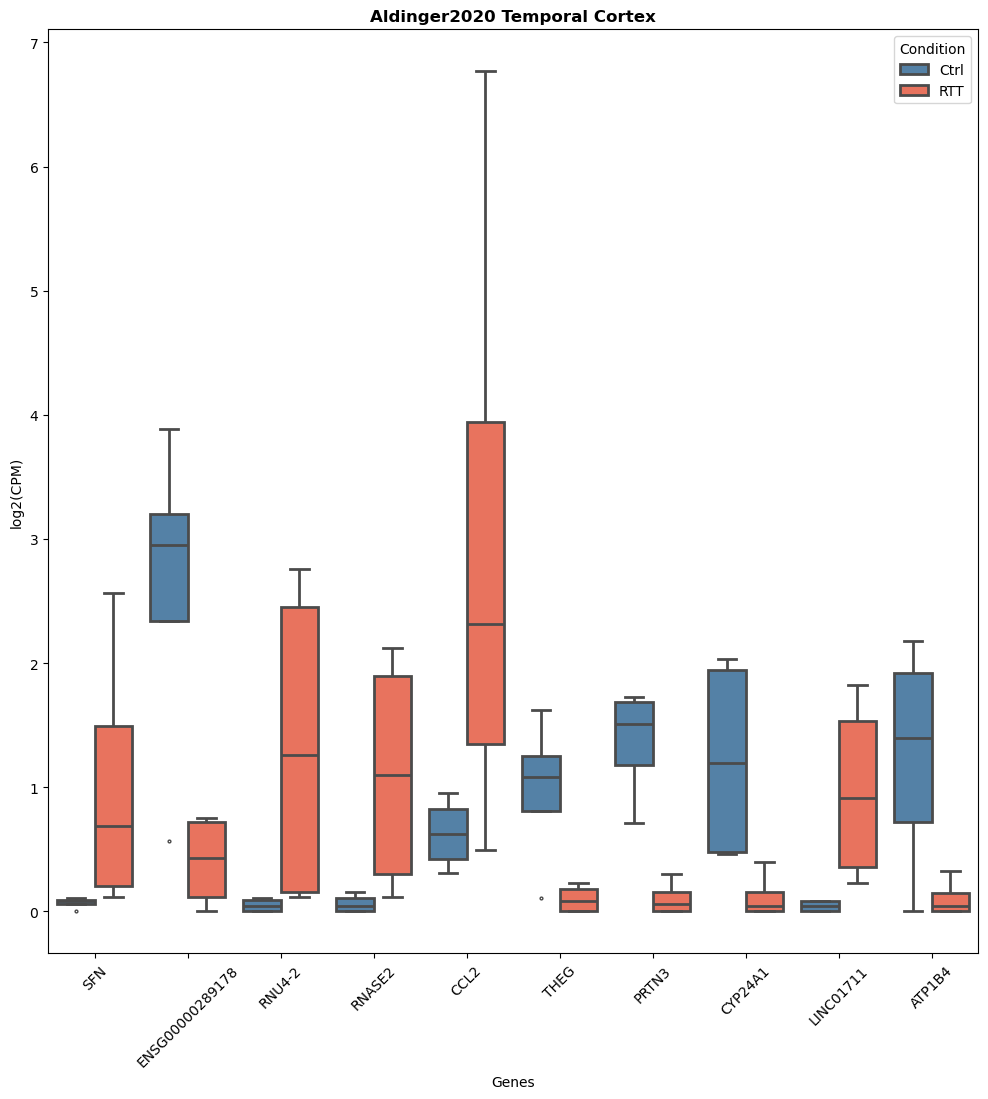

In [28]:
# Assemble the new table
log2cpm_df.insert(0, 'Gene', genes)
goi_df = log2cpm_df[log2cpm_df['Gene'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'Gene', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'Gene', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Aldinger2020 Temporal Cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Genes')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)

